# Product grain and data-quality audit

Notebook này tái lập báo cáo `Research/data_grain_quality_audit.md`. Mục tiêu là xác minh 3.341 dòng/1.157 listing, xác định grain, kiểm tra snapshot, tên trùng, variation/SKU proxy, sales tích lũy và thống kê discount.

Kết luận phải được đọc ở cấp **product listing snapshot**, không phải SKU transaction.

In [1]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 100)
pd.set_option("display.max_rows", 100)

ROOT = Path.cwd()
if not (ROOT / "Dataset").exists():
    ROOT = ROOT.parent

PROCESSED = ROOT / "Dataset/DataProcessed/product_dataset_ready.csv"
RAW_ROOT = ROOT / "Dataset/DataRaw"
df = pd.read_csv(PROCESSED, low_memory=False)
df["date"] = pd.to_datetime(df["date"])

ENTITY = ["country_code", "shop_id", "item_id"]
GRAIN = ENTITY + ["date"]
print(f"Loaded {len(df):,} processed rows from {PROCESSED.relative_to(ROOT)}")

Loaded 3,341 processed rows from Dataset/DataProcessed/product_dataset_ready.csv


In [2]:
# Derived audit fields. Keep `_derived` because promo_percent is not present in source data.
same_as_original = np.isclose(df["price_num"], df["price_original_num"], equal_nan=False)
df["discount_percent_analysis"] = df["discount_percent_num"].where(
    df["discount_percent_num"].notna(), np.where(same_as_original, 0.0, np.nan)
)
df["promo_percent_derived"] = np.where(
    df["price_original_num"] > 0,
    100 * (df["price_original_num"] - df["price_before_promo_num"]) / df["price_original_num"],
    np.nan,
)
df["total_discount_percent_derived"] = np.where(
    df["price_original_num"] > 0,
    100 * (df["price_original_num"] - df["price_num"]) / df["price_original_num"],
    np.nan,
)
latest = df.sort_values("date").drop_duplicates(ENTITY, keep="last").copy()
assert not df["discount_percent_num"].isna().any() or df.loc[df["discount_percent_num"].isna(), "discount_percent_analysis"].notna().all()
print("Derived audit fields created; latest listing table:", len(latest))

Derived audit fields created; latest listing table: 1157


## 1. Xác minh row count, product count và grain

In [3]:
entity_count = len(df[ENTITY].drop_duplicates())
item_count = df["item_id"].nunique()
grain_duplicate_rows = int(df.duplicated(GRAIN, keep=False).sum())
item_multi_scope = (
    df[ENTITY].drop_duplicates().groupby("item_id").size().gt(1).sum()
)

assert len(df) == 3341
assert entity_count == 1157
assert item_count == 1157
assert grain_duplicate_rows == 0
assert item_multi_scope == 0

country_summary = (
    df.groupby("country_code")
      .agg(snapshot_rows=("item_id", "size"), shops=("shop_id", "nunique"), product_listings=("item_id", "nunique"))
      .reset_index()
)
display(country_summary)

key_audit = pd.DataFrame([
    {"candidate": "country_code + shop_id + item_id + date", "unique_values": len(df[GRAIN].drop_duplicates()), "duplicate_rows": grain_duplicate_rows, "decision": "Primary snapshot key"},
    {"candidate": "country_code + shop_id + item_id", "unique_values": entity_count, "duplicate_rows": int(df.duplicated(ENTITY, keep=False).sum()), "decision": "Listing entity key across dates"},
    {"candidate": "item_id + date", "unique_values": len(df[["item_id", "date"]].drop_duplicates()), "duplicate_rows": int(df.duplicated(["item_id", "date"], keep=False).sum()), "decision": "Unique here, but missing business scope"},
    {"candidate": "item_id", "unique_values": item_count, "duplicate_rows": int(df.duplicated(["item_id"], keep=False).sum()), "decision": "Listing ID, not snapshot key"},
    {"candidate": "url + date", "unique_values": len(df[["url", "date"]].drop_duplicates()), "duplicate_rows": int(df.duplicated(["url", "date"], keep=False).sum()), "decision": "Secondary reconciliation key"},
    {"candidate": "key", "unique_values": df["key"].nunique(dropna=True), "duplicate_rows": int(df["key"].isna().sum()), "decision": "Empty; unusable"},
])
display(key_audit)

,country_code,snapshot_rows,shops,product_listings
0,id,1422,10,475
1,vn,1919,10,682


,candidate,unique_values,duplicate_rows,decision
0,country_code + shop_id + item_id + date,3341,0,Primary snapshot key
1,country_code + shop_id + item_id,1157,3329,Listing entity key across dates
2,item_id + date,3341,0,"Unique here, but missing business scope"
3,item_id,1157,3329,"Listing ID, not snapshot key"
4,url + date,3341,0,Secondary reconciliation key
5,key,0,3341,Empty; unusable


In [4]:
shop_summary = (
    df.groupby(["country_code", "shop_id", "shop_name"], dropna=False)
      .agg(snapshot_rows=("item_id", "size"), product_listings=("item_id", "nunique"), snapshot_dates=("date", "nunique"))
      .reset_index()
      .sort_values(["country_code", "shop_id"])
)
display(shop_summary)

,country_code,shop_id,shop_name,snapshot_rows,product_listings,snapshot_dates
0,id,187405886,Alara Cosmetic Official Store,21,7,3
1,id,200048291,Prettywell Official Shop,68,23,3
2,id,430940247,Mooi Pure Glow Official Shop,120,40,3
3,id,697604885,ghaniskin,9,3,3
4,id,779266191,lavojoy Official Shop,117,39,3
5,id,809769142,Glad2Glow Official Store,660,220,3
6,id,859233628,He-Ji Official Store,30,10,3
7,id,1112776376,Scora Official Store,144,48,3
8,id,1368540320,Cyeecare Official Store,198,66,3
9,id,1379527329,ZOICY Official Store,55,19,3


## 2. Duplicate trong raw và processed

In [5]:
raw_parts = []
for path in sorted(RAW_ROOT.glob("country_code=*/dataset=products/shop_id=*/products.csv")):
    part = pd.read_csv(path, low_memory=False)
    part["_path_country"] = re.search(r"country_code=([^/]+)", str(path)).group(1)
    part["_path_shop"] = re.search(r"shop_id=([^/]+)", str(path)).group(1)
    part["_source_file"] = str(path.relative_to(ROOT))
    raw_parts.append(part)
raw = pd.concat(raw_parts, ignore_index=True)
raw_columns = [c for c in raw.columns if not c.startswith("_")]
raw["_country"] = raw["country_code"].fillna(raw["_path_country"])
raw["_shop"] = raw["shop_id"].fillna(raw["_path_shop"])
raw_grain = ["_country", "_shop", "item_id", "date"]
raw_exact_extra = int(raw.duplicated(raw_columns).sum())
raw_grain_extra = int(raw.duplicated(raw_grain).sum())
conflicting_groups = (
    raw.groupby(raw_grain, dropna=False)[raw_columns]
       .apply(lambda x: len(x.drop_duplicates()))
       .gt(1).sum()
)
duplicate_sources = (
    raw.loc[raw.duplicated(raw_grain, keep=False)]
       .groupby("_source_file").size().rename("rows_in_duplicate_groups").reset_index()
)

duplicate_summary = pd.DataFrame({
    "check": ["raw rows", "raw exact duplicate extras", "raw grain duplicate extras", "raw conflicting duplicate groups", "processed rows", "processed grain duplicate extras"],
    "value": [len(raw), raw_exact_extra, raw_grain_extra, int(conflicting_groups), len(df), int(df.duplicated(GRAIN).sum())],
})
display(duplicate_summary)
display(duplicate_sources)
assert len(raw) == 3371 and raw_exact_extra == 30 and raw_grain_extra == 30
assert conflicting_groups == 0

,check,value
0,raw rows,3371
1,raw exact duplicate extras,30
2,raw grain duplicate extras,30
3,raw conflicting duplicate groups,0
4,processed rows,3341
5,processed grain duplicate extras,0


,_source_file,rows_in_duplicate_groups
0,Dataset/DataRaw/country_code=vn/dataset=products/shop_id=289646907/products.csv,60


## 3. Snapshot coverage và khoảng trống

,snapshot_count,listings,share_pct
0,1,12,1.037165
1,2,106,9.161625
2,3,1039,89.801210


Balanced panel cells: 3,471; observed: 3,341; missing: 130


date,2026-07-01,2026-07-02,2026-07-03
country_code,,,
id,1,1,1
vn,101,12,14


,date_pattern,listings
0,2026-07-01 | 2026-07-02 | 2026-07-03,1039
1,2026-07-02 | 2026-07-03,95
2,2026-07-01 | 2026-07-02,6
3,2026-07-01,5
4,2026-07-01 | 2026-07-03,5
5,2026-07-02,4
6,2026-07-03,3


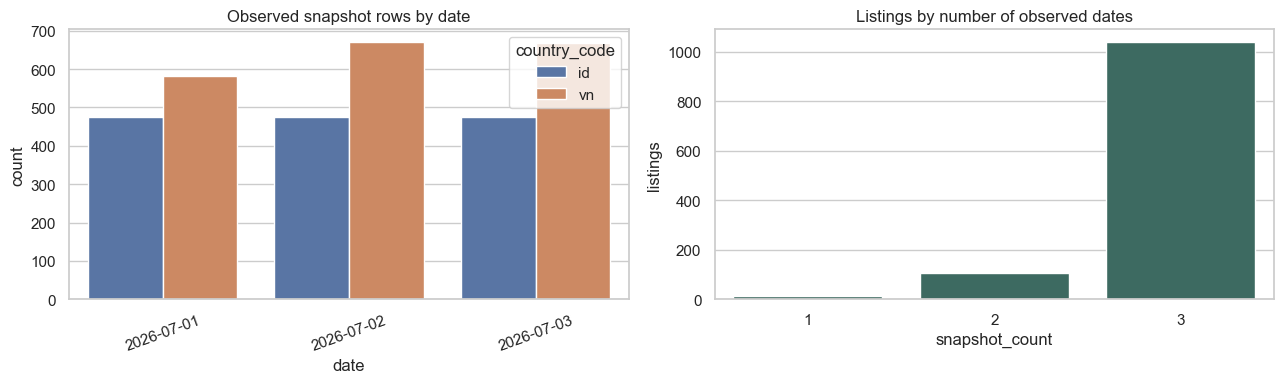

In [6]:
dates = sorted(df["date"].dropna().unique())
entity_dates = (
    df.groupby(ENTITY)["date"]
      .agg(lambda x: " | ".join(d.strftime("%Y-%m-%d") for d in sorted(set(x))))
      .rename("date_pattern")
      .reset_index()
)
entity_dates["snapshot_count"] = entity_dates["date_pattern"].str.count(r"\|") + 1
snapshot_distribution = (
    entity_dates["snapshot_count"].value_counts().sort_index().rename_axis("snapshot_count").reset_index(name="listings")
)
snapshot_distribution["share_pct"] = 100 * snapshot_distribution["listings"] / entity_count
display(snapshot_distribution)

entities = df[ENTITY].drop_duplicates()
all_dates = pd.DataFrame({"date": dates})
panel = entities.merge(all_dates, how="cross")
coverage = panel.merge(df[GRAIN].drop_duplicates().assign(observed=True), on=GRAIN, how="left")
missing = coverage.loc[coverage["observed"].isna()].copy()
missing_by_country_date = (
    missing.groupby(["country_code", "date"]).size().unstack(fill_value=0)
)
print(f"Balanced panel cells: {len(panel):,}; observed: {len(df):,}; missing: {len(missing):,}")
display(missing_by_country_date)
display(entity_dates["date_pattern"].value_counts().rename_axis("date_pattern").reset_index(name="listings"))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.countplot(data=df, x="date", hue="country_code", ax=axes[0])
axes[0].set_title("Observed snapshot rows by date")
axes[0].tick_params(axis="x", rotation=20)
sns.barplot(data=snapshot_distribution, x="snapshot_count", y="listings", color="#357266", ax=axes[1])
axes[1].set_title("Listings by number of observed dates")
plt.tight_layout()
plt.show()

In [7]:
middle_gap_pattern = "2026-07-01 | 2026-07-03"
middle_gaps = entity_dates.loc[entity_dates["date_pattern"] == middle_gap_pattern].merge(
    latest[ENTITY + ["product_name"]], on=ENTITY, how="left"
)
print("Internal middle-date gaps:", len(middle_gaps))
display(middle_gaps)

Internal middle-date gaps: 5


,country_code,shop_id,item_id,date_pattern,snapshot_count,product_name
0,vn,108166524,42955556831,2026-07-01 | 2026-07-03,2,Cà phê đen hòa tan NESCAFÉ Signature Hộp 10 gói ĐẬM ĐÀ TUYỆT HẢO
1,vn,108166524,46804156138,2026-07-01 | 2026-07-03,2,[CÔNG THỨC CẢI TIẾN] Combo 2 Bịch Cà phê Hòa tan NESCAFÉ VỊ NGUYÊN BẢN 46 gói - Đậm thơm hài hòa
2,vn,108166524,49254147237,2026-07-01 | 2026-07-03,2,[CÔNG THỨC CẢI TIẾN] Combo 3 Bịch Cà phê Hòa tan NESCAFÉ VỊ NGUYÊN BẢN 46 gói - Đậm thơm hài hòa
3,vn,108166524,52702489216,2026-07-01 | 2026-07-03,2,[Tặng Ca đá 900ml] Combo 3 Bịch Cà phê Hòa tan NESCAFÉ VỊ NGUYÊN BẢN 46 gói Đậm Thơm Hoàn Hảo (B...
4,vn,108166524,52854131624,2026-07-01 | 2026-07-03,2,Combo 2 hộp Cà phê đen hòa tan NESCAFÉ Signature Hộp 10 gói ĐẬM ĐÀ TUYỆT HẢO


## 4. Trùng tên và SKU/variation proxy

In [8]:
df["name_norm"] = df["product_name_clean"].fillna("").str.strip().str.casefold().str.replace(r"\s+", " ", regex=True)
latest = df.sort_values("date").drop_duplicates(ENTITY, keep="last").copy()
name_versions = df.groupby(ENTITY)["name_norm"].nunique().rename("name_versions")
changed_names = name_versions[name_versions > 1].reset_index()
duplicate_names = (
    latest.groupby(["country_code", "shop_id", "name_norm"], dropna=False)
          .agg(item_count=("item_id", "nunique"), item_ids=("item_id", lambda x: ", ".join(map(str, sorted(set(x))))))
          .reset_index()
          .query("item_count > 1")
          .sort_values(["item_count", "country_code"], ascending=[False, True])
)
print(f"Listings changing name across dates: {len(changed_names)}")
print(f"Duplicate-name groups within the same shop on latest snapshot: {len(duplicate_names)}")
display(duplicate_names)

Listings changing name across dates: 7
Duplicate-name groups within the same shop on latest snapshot: 5


,country_code,shop_id,name_norm,item_count,item_ids
115,id,809769142,[ free gift for 6/25! ]dapatkan hadiah dengan min. pembelian 300rb,2,"46312750544, 55559898858"
295,id,809769142,glad2glow perfect airbrush setting spray -all day glow settingspray -white truffle serumspray 10...,2,"40781619061, 45462078618"
296,id,809769142,glad2glow perfect blur&cover loose powder oil control finishing kontrol minyak tahan lama anti l...,2,"41381802204, 43360906112"
490,vn,108166524,[phiên bản ống hút 4 chiều] sữa lúa mạch nestlé milo 48x180ml không màng co,2,"24814585810, 55211157221"
495,vn,108166524,[tặng bộ 3 hũ đựng gia vị nescafé] bịch cà phê hòa tan nescafé vị nguyên bản 46 gói đậm thơm hoà...,2,"45252508882, 51652982842"


In [9]:
sku_proxy_summary = pd.DataFrame({
    "check": [
        "Product listings",
        "Listings with non-empty tier_variation_name",
        "Listings with at least 2 variation options",
        "Maximum variation option count",
        "Listings with real sku_id/model_id",
    ],
    "value": [
        len(latest),
        int(latest["tier_variation_name"].fillna("").str.strip().ne("").sum()),
        int(latest["tier_variation_options_count"].ge(2).sum()),
        int(latest["tier_variation_options_count"].max()),
        0,
    ],
})
display(sku_proxy_summary)
print("Conclusion: item_id is a product-listing ID. Variation options do not provide stable SKU-level identity or metrics.")

,check,value
0,Product listings,1157
1,Listings with non-empty tier_variation_name,727
2,Listings with at least 2 variation options,582
3,Maximum variation option count,38
4,Listings with real sku_id/model_id,0


Conclusion: item_id is a product-listing ID. Variation options do not provide stable SKU-level identity or metrics.


## 5. Sales có phải lũy kế không, và sales lũy kế có giảm bất thường không?

Dataset không có một field chung tên `sales`. Phần này tách hai khái niệm trước khi kiểm tra:

- `history_sold_value_num`: cumulative sales proxy, được kỳ vọng không giảm.
- `monthly_sold_value_num`: recent/rolling sales proxy, không lũy kế và có thể tăng hoặc giảm.

Vì vậy, cumulative-sales anomaly chỉ được tính trên `history_sold_value_num`.

In [10]:
sales_field_definition = pd.DataFrame([
    {"field": "history_sold_value_num", "meaning": "Historical sold displayed by Shopee", "cumulative_expectation": "Expected cumulative", "decrease_is_anomaly": True},
    {"field": "monthly_sold_value_num", "meaning": "Recent/monthly sold displayed by Shopee", "cumulative_expectation": "Not cumulative (rolling/recent)", "decrease_is_anomaly": False},
])
display(sales_field_definition)

ordered = df.sort_values(ENTITY + ["date"]).copy()
sales_metrics = ["history_sold_value_num", "monthly_sold_value_num", "rating_count_num"]
for metric in sales_metrics:
    ordered[f"previous_{metric}"] = ordered.groupby(ENTITY)[metric].shift(1)
    ordered[f"delta_{metric}"] = ordered[metric] - ordered[f"previous_{metric}"]

def transition_summary(data, metric):
    delta = data[f"delta_{metric}"].dropna()
    return {
        "valid_transitions": len(delta),
        "increase": int((delta > 0).sum()),
        "same": int((delta == 0).sum()),
        "decrease": int((delta < 0).sum()),
        "decrease_pct": 100 * (delta < 0).mean() if len(delta) else np.nan,
    }

transition_rows = []
for metric in sales_metrics:
    for country in ["all", "id", "vn"]:
        scoped = ordered if country == "all" else ordered.loc[ordered["country_code"] == country]
        transition_rows.append({"metric": metric, "country": country, **transition_summary(scoped, metric)})
transition_table = pd.DataFrame(transition_rows)
display(transition_table)

history_all = transition_table.query("metric == 'history_sold_value_num' and country == 'all'").iloc[0]
history_non_decreasing_pct = 100 * (history_all["increase"] + history_all["same"]) / history_all["valid_transitions"]
print(f"History-sold non-decreasing transitions: {int(history_all['increase'] + history_all['same']):,}/{int(history_all['valid_transitions']):,} ({history_non_decreasing_pct:.2f}%)")

both_present = df[["history_sold_value_num", "monthly_sold_value_num"]].dropna()
print("Rows where history_sold < monthly_sold:", int((both_present["history_sold_value_num"] < both_present["monthly_sold_value_num"]).sum()), "of", len(both_present))
print("Negative history_sold values:", int((df["history_sold_value_num"].dropna() < 0).sum()))

,field,meaning,cumulative_expectation,decrease_is_anomaly
0,history_sold_value_num,Historical sold displayed by Shopee,Expected cumulative,True
1,monthly_sold_value_num,Recent/monthly sold displayed by Shopee,Not cumulative (rolling/recent),False


,metric,country,valid_transitions,increase,same,decrease,decrease_pct
0,history_sold_value_num,all,2136,395,1653,88,4.119850
1,history_sold_value_num,id,925,128,797,0,0.000000
2,history_sold_value_num,vn,1211,267,856,88,7.266722
3,monthly_sold_value_num,all,2043,638,992,413,20.215370
4,monthly_sold_value_num,id,893,277,478,138,15.453527
5,monthly_sold_value_num,vn,1150,361,514,275,23.913043
6,rating_count_num,all,2184,950,1184,50,2.289377
7,rating_count_num,id,947,688,259,0,0.000000
8,rating_count_num,vn,1237,262,925,50,4.042037


History-sold non-decreasing transitions: 2,048/2,136 (95.88%)
Rows where history_sold < monthly_sold: 0 of 3138
Negative history_sold values: 0


In [11]:
history_anomalies = ordered.loc[ordered["delta_history_sold_value_num"] < 0].copy()
history_anomalies["history_sold_decrease_flag"] = True
history_anomalies["monthly_also_decreased"] = history_anomalies["delta_monthly_sold_value_num"] < 0
history_anomalies["rating_count_also_decreased"] = history_anomalies["delta_rating_count_num"] < 0
history_anomalies["history_sold_delta_clean"] = np.nan

print("History-sold decrease transitions:", len(history_anomalies))
print("Affected listings:", len(history_anomalies[ENTITY].drop_duplicates()))
print("Monthly sold also decreased:", int(history_anomalies["monthly_also_decreased"].sum()))
print("Rating count also decreased:", int(history_anomalies["rating_count_also_decreased"].sum()))

anomaly_columns = ENTITY + ["date", "product_name", "previous_history_sold_value_num", "history_sold_value_num", "delta_history_sold_value_num", "monthly_also_decreased", "rating_count_also_decreased"]
display(history_anomalies[anomaly_columns].sort_values("delta_history_sold_value_num").head(20))
display(history_anomalies.groupby(["country_code", "shop_id"]).size().sort_values(ascending=False).rename("anomalies").reset_index())

History-sold decrease transitions: 88
Affected listings: 88
Monthly sold also decreased: 86
Rating count also decreased: 24


,country_code,shop_id,item_id,date,product_name,previous_history_sold_value_num,history_sold_value_num,delta_history_sold_value_num,monthly_also_decreased,rating_count_also_decreased
2312,vn,173513432,2989938577,2026-07-03,"[GIAO NHANH] [Quà Tặng Đơn 129k] Combo 2 Bịch Bánh Richy Karo Hoàng Kim Phô Mai, Sợi Gà Truyền T...",30000.0,10000.0,-20000.0,True,False
3068,vn,438905996,21658340202,2026-07-02,[TẶNG QUẠT ĐƠN 180K] Bánh quy Richy KenJu giòn kem dẻo hương vị Nhật,20000.0,6000.0,-14000.0,True,True
3201,vn,438905996,20486486922,2026-07-03,[TẶNG QUÀ ĐƠN TỪ 129K] Bánh mì hoa cúc ngàn lớp Fes'ta Richy,10000.0,199.0,-9801.0,True,True
3211,vn,438905996,24700119875,2026-07-03,[MUA 3 TẶNG 1 QUAT] Combo 3 túi bánh yến mạch Oatmeal Richy 220g- 250g,9000.0,249.0,-8751.0,True,False
3071,vn,438905996,23044095031,2026-07-02,[TẶNG QUẠT ĐƠN 180K] Combo 2-3 bánh quy hành Kenju Richy túi 186g - 279g,9000.0,1000.0,-8000.0,True,True
2228,vn,173513432,42262241242,2026-07-02,[Quà Tặng Đơn 129k] Combo 5 Bánh Tươi Karo Richy 2 Vị: Sợi Gà Truyền Thống & Hoàng Kim Phô Mai -...,8000.0,773.0,-7227.0,True,False
2860,vn,289646907,40205837706,2026-07-03,[LIVESTREAM] [ĐỘC QUYỀN] Hộp 15 Gói Bánh Nướng Giòn Vị Bơ Tỏi Orion C'est Bon Baguette (540g),7000.0,1000.0,-6000.0,True,True
3082,vn,438905996,23560645214,2026-07-02,"[TẶNG QUẠT ĐƠN 180K] [BAO BÌ MỚI] Bánh quy Kenju Richy vị rau củ, vị tôm túi 192g, hộp 288g, Bán...",10000.0,4000.0,-6000.0,True,True
1622,vn,108166524,47254151647,2026-07-03,[CÔNG THỨC CẢI TIẾN] Combo 3 hộp Cà phê Hòa tan NESCAFÉ VỊ NGUYÊN BẢN 20 gói - Đậm thơm hài hòa,10000.0,4000.0,-6000.0,True,False
2911,vn,430972539,44324603727,2026-07-02,COMBO 2 Kẹo Cứng - Mềm Nhiều vị từ Alpenliebe,7000.0,1000.0,-6000.0,True,False


,country_code,shop_id,anomalies
0,vn,173513432,25
1,vn,1145316676,15
2,vn,438905996,13
3,vn,1546895026,10
4,vn,108166524,8
5,vn,213989179,8
6,vn,289646907,6
7,vn,430972539,2
8,vn,140360136,1


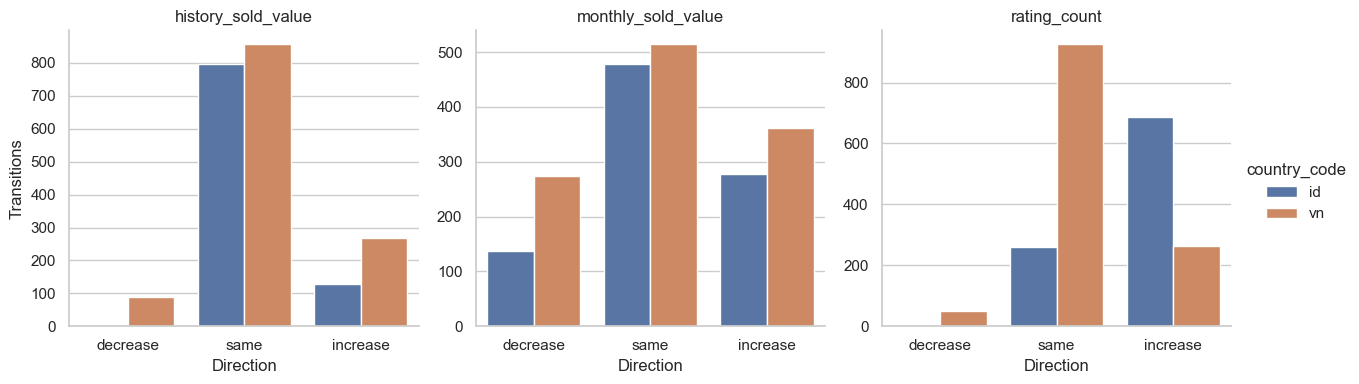

In [12]:
plot_rows = []
for metric in sales_metrics:
    delta_col = f"delta_{metric}"
    temp = ordered.loc[ordered[delta_col].notna(), ["country_code", delta_col]].copy()
    temp["direction"] = np.select([temp[delta_col] < 0, temp[delta_col] > 0], ["decrease", "increase"], default="same")
    counts = temp.groupby(["country_code", "direction"]).size().reset_index(name="transitions")
    counts["metric"] = metric.replace("_num", "")
    plot_rows.append(counts)
plot_data = pd.concat(plot_rows, ignore_index=True)

g = sns.catplot(data=plot_data, x="direction", y="transitions", hue="country_code", col="metric", kind="bar", sharey=False, height=4, aspect=1.05, order=["decrease", "same", "increase"])
g.set_titles("{col_name}")
g.set_axis_labels("Direction", "Transitions")
plt.show()

### Trả lời hai câu hỏi

**1. Sales có phải lũy kế không?**

Không có câu trả lời chung: `history_sold_value` là cumulative proxy được kỳ vọng lũy kế; `monthly_sold_value` là recent/rolling proxy và không lũy kế. Cả hai đều là số Shopee hiển thị, không phải order ledger.

**2. Sales lũy kế có giảm bất thường không?**

Có, nếu kiểm tra `history_sold_value`: 88/2.136 transition (4,12%) giảm và vi phạm kỳ vọng không giảm. Các transition này phải được flag và loại khỏi incremental-sales calculation.

413 lần giảm của `monthly_sold_value` không được cộng vào cumulative anomaly vì field này không lũy kế. Không lấy `diff(monthly_sold_value)` làm daily sales. Không âm thầm đổi delta lỗi thành 0; giữ raw, flag và đặt clean delta thành null.

## 6. Discount percent và promo percent derived

In [13]:
raw_discount_missing = int(df["discount_percent_num"].isna().sum())
missing_but_price_differs = int((df["discount_percent_num"].isna() & ~same_as_original).sum())
valid_discount = df.loc[df["discount_percent_num"].notna()].copy()
exact_rounded_match = int(np.isclose(valid_discount["discount_percent_num"], valid_discount["total_discount_percent_derived"].round()).sum())
within_one_point = int((valid_discount["discount_percent_num"].sub(valid_discount["total_discount_percent_derived"]).abs() <= 1).sum())

formula_audit = pd.DataFrame({
    "check": [
        "Raw discount_percent present",
        "Raw discount_percent missing",
        "Missing discount but price differs from original",
        "Exact match after rounding vs total price discount",
        "Within 1 percentage point vs total price discount",
        "promotion_id present",
    ],
    "rows": [
        int(df["discount_percent_num"].notna().sum()), raw_discount_missing, missing_but_price_differs,
        exact_rounded_match, within_one_point, int(df["promotion_id_num"].notna().sum()),
    ],
})
display(formula_audit)
print("No source column named promo_percent:", "promo_percent" not in df.columns)

,check,rows
0,Raw discount_percent present,3034
1,Raw discount_percent missing,307
2,Missing discount but price differs from original,0
3,Exact match after rounding vs total price discount,3007
4,Within 1 percentage point vs total price discount,3034
5,promotion_id present,3341


No source column named promo_percent: True


,metric,country,n,min,p25,median,mean,p75,max,zero,positive
0,discount_percent_analysis,all,1157,0.0,16.00,26.00,33.15,50.00,99.00,84,1073
1,discount_percent_analysis,id,475,0.0,40.00,53.00,49.96,63.00,99.00,57,418
2,discount_percent_analysis,vn,682,0.0,12.00,19.00,21.44,27.00,98.00,27,655
3,promo_percent_derived,all,1157,0.0,0.00,16.00,26.06,49.03,99.99,315,842
4,promo_percent_derived,id,475,0.0,38.38,51.60,49.40,63.40,99.99,59,416
5,promo_percent_derived,vn,682,0.0,0.00,5.51,9.81,15.97,97.50,256,426


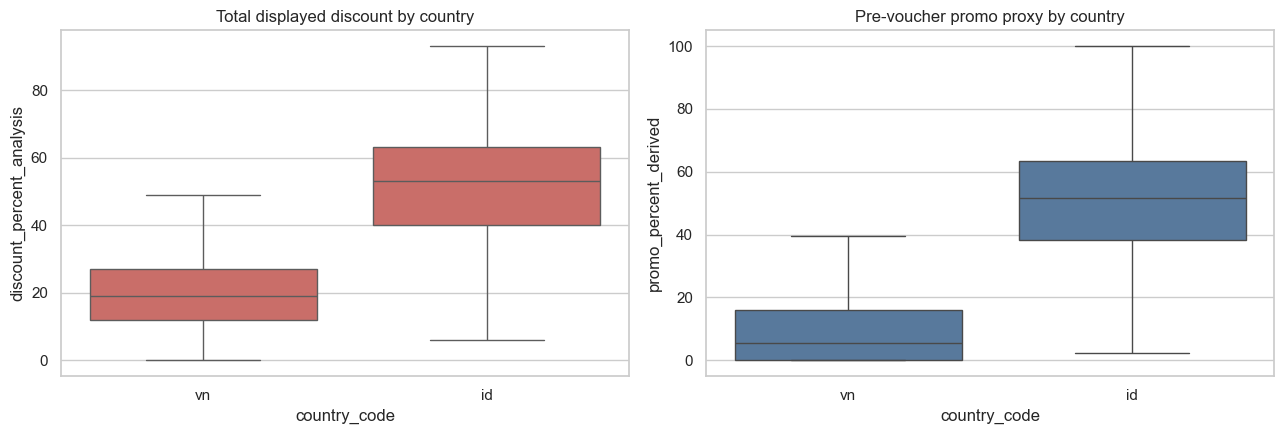

In [14]:
def descriptive_stats(frame, metric, country):
    values = frame[metric].dropna()
    return {
        "metric": metric, "country": country, "n": len(values),
        "min": values.min(), "p25": values.quantile(0.25), "median": values.median(),
        "mean": values.mean(), "p75": values.quantile(0.75), "max": values.max(),
        "zero": int(values.eq(0).sum()), "positive": int(values.gt(0).sum()),
    }

discount_stats = []
for metric in ["discount_percent_analysis", "promo_percent_derived"]:
    discount_stats.append(descriptive_stats(latest, metric, "all"))
    for country, scoped in latest.groupby("country_code"):
        discount_stats.append(descriptive_stats(scoped, metric, country))
discount_stats = pd.DataFrame(discount_stats)
numeric_display = ["min", "p25", "median", "mean", "p75", "max"]
discount_stats[numeric_display] = discount_stats[numeric_display].round(2)
display(discount_stats.sort_values(["metric", "country"]))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.boxplot(data=latest, x="country_code", y="discount_percent_analysis", showfliers=False, color="#d95f59", ax=axes[0])
axes[0].set_title("Total displayed discount by country")
axes[0].set_ylabel("discount_percent_analysis")
sns.boxplot(data=latest, x="country_code", y="promo_percent_derived", showfliers=False, color="#4c78a8", ax=axes[1])
axes[1].set_title("Pre-voucher promo proxy by country")
axes[1].set_ylabel("promo_percent_derived")
plt.tight_layout()
plt.show()

### Promotion ID: campaign hay từng sản phẩm?

`promotion_id` không phải ID sản phẩm. Audit cardinality bên dưới kiểm tra một ID phủ bao nhiêu listing, một listing đổi bao nhiêu ID qua các ngày và giá trị sentinel `0`. Cách hiểu an toàn là ID promotion/offer gắn với listing-snapshot; chưa đủ metadata để gọi chắc chắn là campaign marketing cấp cao.

`discount_percent` được kiểm định riêng trên nhóm có và không có structured voucher để xác định nó là promo-only hay tổng discount.

In [15]:
df["promotion_id_clean"] = df["promotion_id_num"].where(df["promotion_id_num"].ne(0))
promotion_summary = pd.DataFrame({
    "metric": ["rows", "promotion_id = 0", "nonzero promotion IDs", "listings with 1 ID incl. 0", "listings with 2+ IDs incl. 0"],
    "value": [len(df), int(df["promotion_id_num"].eq(0).sum()), int(df["promotion_id_clean"].nunique()),
              int(df.groupby(ENTITY)["promotion_id_num"].nunique().eq(1).sum()),
              int(df.groupby(ENTITY)["promotion_id_num"].nunique().ge(2).sum())],
})
display(promotion_summary)

promotion_scope = (
    df.loc[df["promotion_id_clean"].notna()]
      .groupby("promotion_id_clean")
      .agg(snapshot_rows=("item_id", "size"), items=("item_id", "nunique"), shops=("shop_id", "nunique"), dates=("date", "nunique"))
      .sort_values(["items", "snapshot_rows"], ascending=False)
)
display(promotion_scope.head(15))
print("Nonzero promotion IDs spanning multiple shops:", int(promotion_scope["shops"].gt(1).sum()))

,metric,value
0,rows,3341
1,promotion_id = 0,874
2,nonzero promotion IDs,106
3,listings with 1 ID incl. 0,589
4,listings with 2+ IDs incl. 0,568


,snapshot_rows,items,shops,dates
promotion_id_clean,,,,
4.760433e+14,300,155,1,2
4.760415e+14,155,155,1,1
4.761653e+14,210,92,1,3
4.735020e+14,85,85,2,1
4.757204e+14,62,62,1,1
9.260029e+14,134,59,1,3
4.745628e+14,58,58,2,1
4.757115e+14,104,55,1,2
4.758283e+14,97,50,1,2


Nonzero promotion IDs spanning multiple shops: 14


In [16]:
discount_formula = df.loc[df["discount_percent_num"].notna()].copy()
discount_formula["has_structured_voucher_audit"] = discount_formula["voucher_discount_num"].fillna(0).gt(0)
discount_formula["pre_final_reduction_proxy"] = 100 * (discount_formula["price_original_num"] - discount_formula["price_before_promo_num"]) / discount_formula["price_original_num"]
discount_formula["matches_total_within_1pp"] = discount_formula["discount_percent_num"].sub(discount_formula["total_discount_percent_derived"]).abs().le(1)
discount_formula["matches_pre_final_within_1pp"] = discount_formula["discount_percent_num"].sub(discount_formula["pre_final_reduction_proxy"]).abs().le(1)
discount_component_audit = (
    discount_formula.groupby("has_structured_voucher_audit")
      .agg(rows=("item_id", "size"), matches_total=("matches_total_within_1pp", "sum"), matches_pre_final=("matches_pre_final_within_1pp", "sum"))
      .reset_index()
)
display(discount_component_audit)

voucher_rows = discount_formula.loc[discount_formula["has_structured_voucher_audit"]]
voucher_amount_exact = np.isclose(voucher_rows["price_before_promo_num"] - voucher_rows["price_num"], voucher_rows["voucher_discount_num"])
print("Voucher amount exactly matches price_before_promo - price:", int(voucher_amount_exact.sum()), "of", len(voucher_rows))
print("Conclusion: discount_percent is total displayed discount to final price, not promo-only.")

,has_structured_voucher_audit,rows,matches_total,matches_pre_final
0,False,1454,1454,1287
1,True,1580,1580,0


Voucher amount exactly matches price_before_promo - price: 1011 of 1580
Conclusion: discount_percent is total displayed discount to final price, not promo-only.


## 7. Voucher và các yếu tố liên quan

Phân tích tách hai khái niệm:

- **Structured voucher**: `voucher_discount_num > 0`, có thể định lượng bằng code, số tiền, min spend và thời gian.
- **Voucher/offer label**: `vouchers_count > 0`, chỉ cho biết có badge/nhãn UI và không nhất thiết là voucher tiền tệ.

Thiếu structured voucher không chứng minh ngoài thực tế không có voucher; nó chỉ phản ánh những gì export cung cấp.

In [17]:
df["has_structured_voucher"] = df["voucher_discount_num"].fillna(0).gt(0)
df["has_voucher_label"] = df["vouchers_count"].fillna(0).gt(0)
latest = df.sort_values("date").drop_duplicates(ENTITY, keep="last").copy()

def voucher_presence(frame, scope):
    rows = []
    for country in ["all", "id", "vn"]:
        part = frame if country == "all" else frame.loc[frame["country_code"] == country]
        rows.append({
            "scope": scope, "country": country, "rows_or_listings": len(part),
            "structured_voucher": int(part["has_structured_voucher"].sum()),
            "structured_rate_pct": 100 * part["has_structured_voucher"].mean(),
            "offer_label": int(part["has_voucher_label"].sum()),
        })
    return rows

presence = pd.DataFrame(voucher_presence(df, "all_snapshots") + voucher_presence(latest, "latest_listing"))
presence["structured_rate_pct"] = presence["structured_rate_pct"].round(2)
display(presence)

latest_cross = (
    latest.groupby(["has_structured_voucher", "has_voucher_label"]).size()
          .rename("listings").reset_index()
)
display(latest_cross)

structured = df.loc[df["has_structured_voucher"]].copy()
required = ["voucher_code", "voucher_discount_num", "voucher_min_spend_num", "voucher_start_time_num", "voucher_end_time_num"]
completeness = pd.DataFrame({"field": required, "present_rows": [int(structured[c].notna().sum()) for c in required]})
display(completeness)
assert len(structured) == 1580
assert completeness["present_rows"].eq(1580).all()

,scope,country,rows_or_listings,structured_voucher,structured_rate_pct,offer_label
0,all_snapshots,all,3341,1580,47.29,1720
1,all_snapshots,id,1422,0,0.00,630
2,all_snapshots,vn,1919,1580,82.33,1090
3,latest_listing,all,1157,588,50.82,636
4,latest_listing,id,475,0,0.00,211
5,latest_listing,vn,682,588,86.22,425


,has_structured_voucher,has_voucher_label,listings
0,False,False,313
1,False,True,256
2,True,False,208
3,True,True,380


,field,present_rows
0,voucher_code,1580
1,voucher_discount_num,1580
2,voucher_min_spend_num,1580
3,voucher_start_time_num,1580
4,voucher_end_time_num,1580


In [18]:
latest_voucher = latest.loc[latest["has_structured_voucher"]].copy()
latest_voucher["voucher_rate_pre_price"] = 100 * latest_voucher["voucher_discount_num"] / latest_voucher["price_before_promo_num"]
latest_voucher["voucher_rate_original_price"] = 100 * latest_voucher["voucher_discount_num"] / latest_voucher["price_original_num"]

value_stats = latest_voucher[["voucher_discount_num", "voucher_min_spend_num", "voucher_rate_pre_price", "voucher_rate_original_price"]].describe(percentiles=[0.25, 0.5, 0.75]).T
display(value_stats[["count", "min", "25%", "50%", "mean", "75%", "max"]].round(2))

structured["voucher_price_formula_gap"] = structured["price_before_promo_num"] - structured["voucher_discount_num"] - structured["price_num"]
both_times = structured["voucher_start_time_num"].notna() & structured["voucher_end_time_num"].notna()
snapshot_time = pd.to_datetime(structured["date"], utc=True)
start_time = pd.to_datetime(structured["voucher_start_time_num"], unit="s", utc=True)
end_time = pd.to_datetime(structured["voucher_end_time_num"], unit="s", utc=True)

price_below_min = structured["price_num"] < structured["voucher_min_spend_num"]
relation_checks = pd.DataFrame([
    {"check": "price_before_promo >= min_spend", "passed": int((structured["price_before_promo_num"] >= structured["voucher_min_spend_num"]).sum()), "tested": len(structured)},
    {"check": "price < min_spend", "passed": int(price_below_min.sum()), "tested": len(structured)},
    {"check": "price + voucher_discount >= min_spend where price < min", "passed": int(((structured["price_num"] + structured["voucher_discount_num"] >= structured["voucher_min_spend_num"]) & price_below_min).sum()), "tested": int(price_below_min.sum())},
    {"check": "price formula exact", "passed": int(structured["voucher_price_formula_gap"].eq(0).sum()), "tested": len(structured)},
    {"check": "start_time <= end_time", "passed": int((structured.loc[both_times, "voucher_start_time_num"] <= structured.loc[both_times, "voucher_end_time_num"]).sum()), "tested": int(both_times.sum())},
    {"check": "snapshot date timestamp inside validity", "passed": int(((snapshot_time >= start_time) & (snapshot_time <= end_time)).sum()), "tested": int(both_times.sum())},
])
display(relation_checks)

structured["voucher_duration_hours"] = (structured["voucher_end_time_num"] - structured["voucher_start_time_num"]) / 3600
display(structured["voucher_duration_hours"].value_counts().sort_index().rename_axis("duration_hours").reset_index(name="snapshots"))

,count,min,25%,50%,mean,75%,max
voucher_discount_num,588.0,5000.0,10675.00,19532.50,51531.50,75055.00,665820.0
voucher_min_spend_num,588.0,50000.0,50000.00,150000.00,226528.91,250000.00,3000000.0
voucher_rate_pre_price,588.0,9.0,10.00,11.63,12.60,15.90,22.0
voucher_rate_original_price,588.0,4.0,9.02,10.75,11.51,14.02,22.0


,check,passed,tested
0,price_before_promo >= min_spend,1580,1580
1,price < min_spend,335,1580
2,price + voucher_discount >= min_spend where price < min,335,335
3,price formula exact,1011,1580
4,start_time <= end_time,1580,1580
5,snapshot date timestamp inside validity,1580,1580


,duration_hours,snapshots
0,23.983333,808
1,47.983333,385
2,95.983333,377
3,119.983333,10


has_structured_voucher,False,True
previous_has_voucher,,
False,1125,67
True,59,933


Voucher code changed while voucher remained present: 798 of 933


,has_structured_voucher,listings,shops,median_monthly_sold,median_price,median_revenue_proxy
0,False,94,6,284.5,38700.0,10873500.0
1,True,588,9,205.0,143237.5,38776320.0


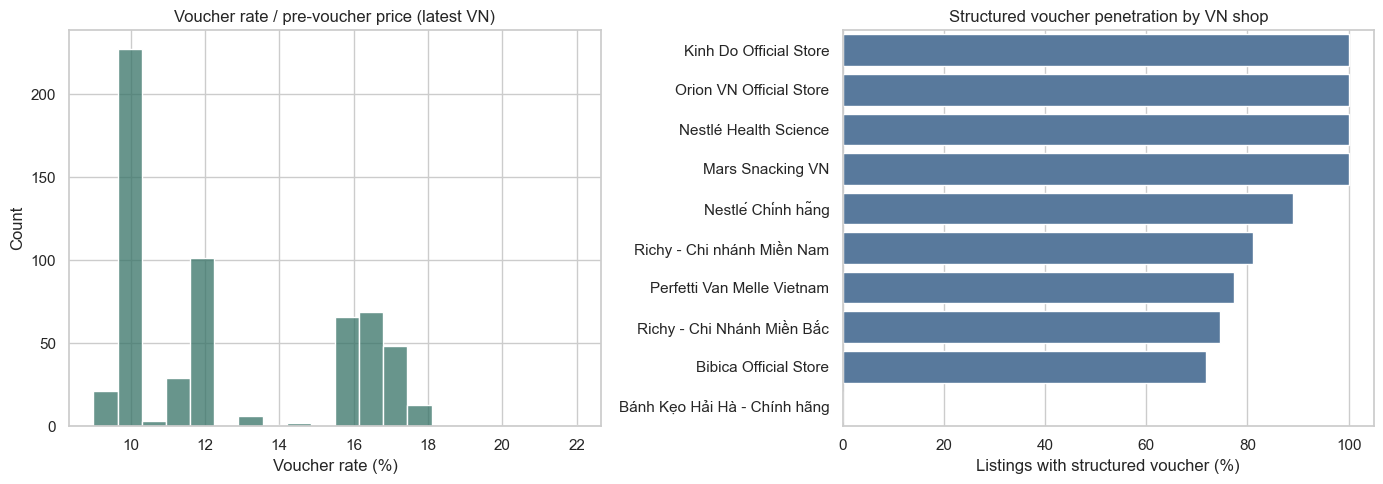

In [19]:
voucher_ordered = df.sort_values(ENTITY + ["date"]).copy()
voucher_group = voucher_ordered.groupby(ENTITY)
voucher_ordered["previous_has_voucher"] = voucher_group["has_structured_voucher"].shift(1)
voucher_ordered["previous_voucher_code"] = voucher_group["voucher_code"].shift(1)
voucher_ordered["previous_date"] = voucher_group["date"].shift(1)
voucher_transitions = voucher_ordered.loc[voucher_ordered["previous_date"].notna()].copy()
status_transitions = pd.crosstab(voucher_transitions["previous_has_voucher"], voucher_transitions["has_structured_voucher"])
display(status_transitions)

both_voucher = voucher_transitions["previous_has_voucher"].eq(True) & voucher_transitions["has_structured_voucher"]
code_changed = both_voucher & voucher_transitions["previous_voucher_code"].fillna("").ne(voucher_transitions["voucher_code"].fillna(""))
print("Voucher code changed while voucher remained present:", int(code_changed.sum()), "of", int(both_voucher.sum()))

latest_vn = latest.loc[latest["country_code"] == "vn"].copy()
latest_vn["estimated_revenue_proxy"] = latest_vn["price_num"] * latest_vn["monthly_sold_value_num"]
descriptive_effectiveness = (
    latest_vn.groupby("has_structured_voucher")
             .agg(listings=("item_id", "size"), shops=("shop_id", "nunique"), median_monthly_sold=("monthly_sold_value_num", "median"), median_price=("price_num", "median"), median_revenue_proxy=("estimated_revenue_proxy", "median"))
             .reset_index()
)
display(descriptive_effectiveness)

shop_penetration = (
    latest_vn.groupby(["shop_id", "shop_name"])
             .agg(listings=("item_id", "size"), voucher_rate=("has_structured_voucher", "mean"))
             .reset_index()
)
shop_penetration["voucher_rate_pct"] = 100 * shop_penetration["voucher_rate"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(data=latest_voucher, x="voucher_rate_pre_price", bins=20, color="#357266", ax=axes[0])
axes[0].set_title("Voucher rate / pre-voucher price (latest VN)")
axes[0].set_xlabel("Voucher rate (%)")
shop_plot = shop_penetration.sort_values("voucher_rate_pct", ascending=False)
sns.barplot(data=shop_plot, y="shop_name", x="voucher_rate_pct", color="#4c78a8", ax=axes[1])
axes[1].set_title("Structured voucher penetration by VN shop")
axes[1].set_xlabel("Listings with structured voucher (%)")
axes[1].set_ylabel("")
plt.tight_layout()
plt.show()

### Voucher conclusions and guardrails

- Structured voucher xuất hiện ở 1.580/3.341 snapshot và chỉ có trong export VN; ID vẫn có offer labels nên không được suy rộng rằng thị trường ID không có voucher ngoài thực tế.
- `price` đã phản ánh voucher/ưu đãi hiển thị; không trừ `voucher_discount` lần nữa.
- Không cộng `discount_percent` với voucher rate vì discount source gần với tổng giảm từ giá gốc tới giá cuối.
- Voucher là thuộc tính theo snapshot: trạng thái và code có thể đổi qua ngày.
- So sánh có/không voucher là mô tả quan sát, chịu confounding bởi shop, category và mức giá; không chứng minh causal uplift.
- Đánh giá hiệu quả thật cần order/GMV, redemption, voucher funding/cost, thời gian dài hơn và control hoặc causal design.

## 8. Final audit decisions

1. Grain: `country_code + shop_id + item_id + date`.
2. Entity: product listing, không phải SKU.
3. Snapshot: processed không trùng; panel có 130 khoảng trống và 5 internal middle-date gaps.
4. Tên: không phải khóa; có tên trùng và name change.
5. Sales: không có một field sales chung. `history_sold_value` là cumulative proxy có 88 transition giảm bất thường; `monthly_sold_value` là rolling proxy, nên giảm không tự động là lỗi.
6. Discount: source discount gần như bằng tổng giảm từ giá gốc tới giá cuối.
7. Promo percent: không tồn tại trong source; chỉ dùng `promo_percent_derived` với caveat.
8. Voucher: phải tách structured voucher khỏi offer labels; không trừ voucher hai lần và không kết luận causal uplift từ so sánh nhóm.
9. Agent phải trả về evidence và limitation, không suy diễn SKU-level sales hay causal promotion uplift.